# Part 1: Making the Error Model for Dropping T's

In [2]:
import numpy as np
import sys 

In [3]:
# one qubit gates
H = np.array([[1, 1], [1, -1]]) / np.sqrt(2)
T = np.array([[1, 0], [0, np.exp(1j * np.pi / 4)]])
Z = np.array([[1, 0], [0, -1]])

# two-qubit gates
I2 = np.eye(2, dtype=complex)
I4 = np.eye(4, dtype=complex)
HI = np.kron(H, I2)
IH = np.kron(I2, H)
TI = np.kron(T, I2)
IT = np.kron(I2, T)
TT = np.kron(T, T)
CNOT01 = np.array([[1,0,0,0],[0,1,0,0],[0,0,0,1],[0,0,1,0]], dtype=complex)
CNOT10 = np.array([[1,0,0,0],[0,0,0,1],[0,0,1,0],[0,1,0,0]], dtype=complex)

gate_set_2q = [HI, IH, TI, IT, TT, CNOT01, CNOT10]


In [ ]:
# functions for rotations and diamon norm etc

def rotation_angle(U): # rotation angle of some unitary in SU(2)
    phase = np.sqrt(np.linalg.det(U))
    U_su2 = U / phase
    return 2 * np.arccos(np.clip(np.real(np.trace(U_su2)) / 2, -1, 1))


def diamond_norm(U, V): # diamon norm
    return 2 * np.sin(rotation_angle(U.conj().T @ V) / 2)


def random_segment(k, rng): # random draw from {H,T}
    U = np.eye(2, dtype=complex)
    for _ in range(k):
        U = (H if rng.random() < 0.5 else T) @ U
    return U

# two qubit functions

import qutip as qt

# fast path for diamond norm!
def diamond_norm_2q(U, V):
    U_qt = qt.Qobj(U, dims=[[2,2],[2,2]])
    V_qt = qt.Qobj(V, dims=[[2,2],[2,2]])
    return qt.dnorm(U_qt, V_qt)  


def random_segment_2q(k, rng):
    U = I4.copy()
    for _ in range(k):
        U = gate_set_2q[rng.integers(len(gate_set_2q))] @ U
    return U


In [5]:
# transfer matrix
s = 1 / np.sqrt(2)
M = 0.5 * np.array([
    [s,     -s,     1],
    [s,  s - 1,     0],
    [1,      0,     1],
])
n0 = np.array([0.0, 0.0, 1.0])
dominant = max(np.abs(np.linalg.eigvals(M))) 
print(dominant)

print(np.linalg.eigvals(M))

0.8837240795964854
[ 0.88372408+0.j         -0.08830865+0.27396941j -0.08830865-0.27396941j]


# Part 1: Error model for T-dropping

# Single qubit circuits

### Dropping 2 T gates at k-separation

In [11]:

# calculating the diamond error for two dropped T gates separated by k random gates by MC
rng = np.random.default_rng(42)

N = 50000
k_values = [0, 1, 2, 5, 10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100, 150, 200]
haar_limit = 0.975

k_list = []
mean_errors = []

print("k    diamond error")
for k in k_values:
    diams = []
    for _ in range(N):
        B = random_segment(k, rng)
        diams.append(diamond_norm(T @ B @ T, B))
    k_list.append(k)
    mean_errors.append(np.mean(diams))

    print(f"{k:3d}  {np.mean(diams):.4f}")


k    diamond error
  0  1.4142
  1  1.2295
  2  1.2292
  5  1.1712
 10  1.0719
 15  1.0215
 20  1.0018
 30  0.9823
 40  0.9753
 50  0.9737
 60  0.9756
 70  0.9747
 80  0.9742
 90  0.9758
100  0.9725
150  0.9729
200  0.9774


<>:11: SyntaxWarning: invalid escape sequence '\d'
<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:11: SyntaxWarning: invalid escape sequence '\d'
<>:12: SyntaxWarning: invalid escape sequence '\d'
/var/folders/hh/4jxv48xx1nv34jrj383q31yh0000gn/T/ipykernel_8566/872366689.py:11: SyntaxWarning: invalid escape sequence '\d'
  ax.set_ylabel('Mean diamond error $\\delta_\diamond$', fontsize=12)
/var/folders/hh/4jxv48xx1nv34jrj383q31yh0000gn/T/ipykernel_8566/872366689.py:12: SyntaxWarning: invalid escape sequence '\d'
  ax.set_title('Mean diamond error $\\delta_\diamond$ over gate separation $k$', fontsize=12)


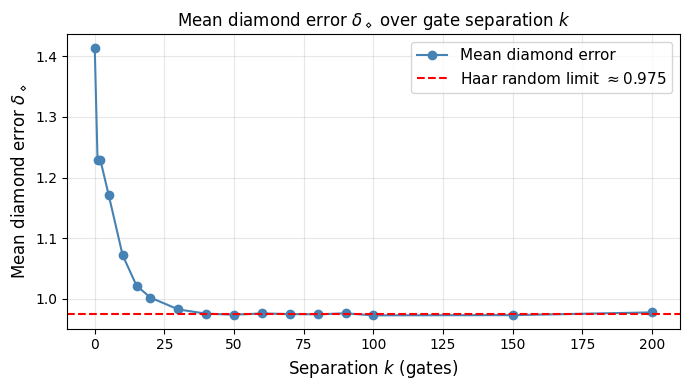

In [26]:
# plotting the convergence

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(k_list, mean_errors, 'o-', color='steelblue', label='Mean diamond error')
ax.axhline(y=haar_limit, color='red', linestyle='--', label=f'Haar random limit $\\approx {haar_limit}$')

ax.set_xlabel('Separation $k$ (gates)', fontsize=12)
ax.set_ylabel('Mean diamond error $\\delta_\diamond$', fontsize=12)
ax.set_title('Mean diamond error $\\delta_\diamond$ over gate separation $k$', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('diamond_error_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

### Dropping m $T$-gates at $k$-separation

This is something I explored briefly: studying the behaviour of the diamond norm error when $m$ T-gates are dropped, each at $k$ separation. I did not include this in the dissertation as I do not think it is very instructive on the behaviour of the diamond error. There is periodic behaviour at k = 0 which is just due to rotations stacking trivially.

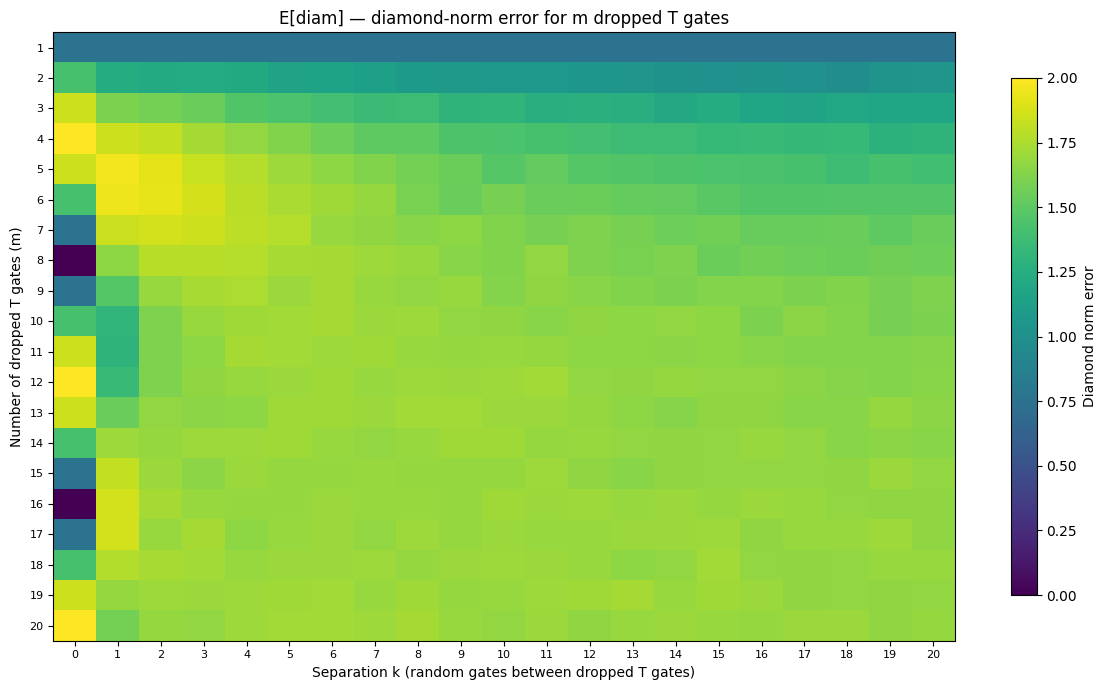

In [ ]:
import matplotlib.pyplot as plt

rng2 = np.random.default_rng(7)
N2 = 500

m_vals = list(range(1, 21))
k_vals = list(range(0, 21))

data = np.zeros((len(m_vals), len(k_vals)))

for i_m, m in enumerate(m_vals):
    for i_k, k in enumerate(k_vals):
        errors = []
        for _ in range(N2):
            E_u = np.eye(2, dtype=complex)
            cumB = np.eye(2, dtype=complex)
            for i in range(m):
                if i > 0:
                    cumB = random_segment(k, rng2) @ cumB
                E_u = cumB.conj().T @ T.conj().T @ cumB @ E_u
            errors.append(2 * np.sin(rotation_angle(E_u) / 2))
        data[i_m, i_k] = np.mean(errors)

fig, ax = plt.subplots(figsize=(12, 7))

im = ax.imshow(data, aspect='auto', cmap='viridis',
               origin='upper', interpolation='nearest')

ax.set_xticks(range(len(k_vals)))
ax.set_xticklabels([str(k) for k in k_vals], fontsize=8)
ax.set_yticks(range(len(m_vals)))
ax.set_yticklabels([str(m) for m in m_vals], fontsize=8)
ax.set_xlabel('Separation k')
ax.set_ylabel('Number of dropped T gates (m)')
ax.set_title('Diamond-norm error for m dropped T gates')

cbar = fig.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label('Diamond norm error')

plt.tight_layout()
plt.show()


# Two qubit circuits

## Dropping 2 T-gates at k-separation

In [27]:
import cvxpy
print(cvxpy.__version__)

1.8.2


In [28]:
import qutip as qt
print(qt.dnorm)

<function dnorm at 0x10da63ba0>


In [52]:
rng_2q = np.random.default_rng(42)
N_2q = 5000

# there should be 5 distinct cases if we enumerate and take into account of symmetry between the two qubits.

cases = [
    ('TI,TI', TI, TI),
    ('TT,TT', TT, TT),
    ('TI,IT', TI, IT),
    ('TI,TT', TI, TT),
    ('TT,TI', TT, TI),
]

k_values = [0, 1, 2, 5, 10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100, 150, 200]
results = {label: [] for label, _, _ in cases}

# print(f"{'k':>3}  {'TI,TI':>8}  {'TT,TT':>8}  {'TI,IT':>8}  {'TI,TT':>8}  {'TT,TI':>8}")
for k in k_values:
    for label, g1, g2 in cases:
        diams = []
        for _ in range(N_2q):
            B = random_segment_2q(k, rng_2q)
            C_full = g2 @ B @ g1
            C_drop = B
            diams.append(diamond_norm_2q(C_full, C_drop))
        results[label].append(np.mean(diams))

<>:10: SyntaxWarning: invalid escape sequence '\d'
<>:10: SyntaxWarning: invalid escape sequence '\d'
/var/folders/hh/4jxv48xx1nv34jrj383q31yh0000gn/T/ipykernel_8566/674386576.py:10: SyntaxWarning: invalid escape sequence '\d'
  ax.set_ylabel('Mean diamond error $\\delta_\diamond$', fontsize=15)


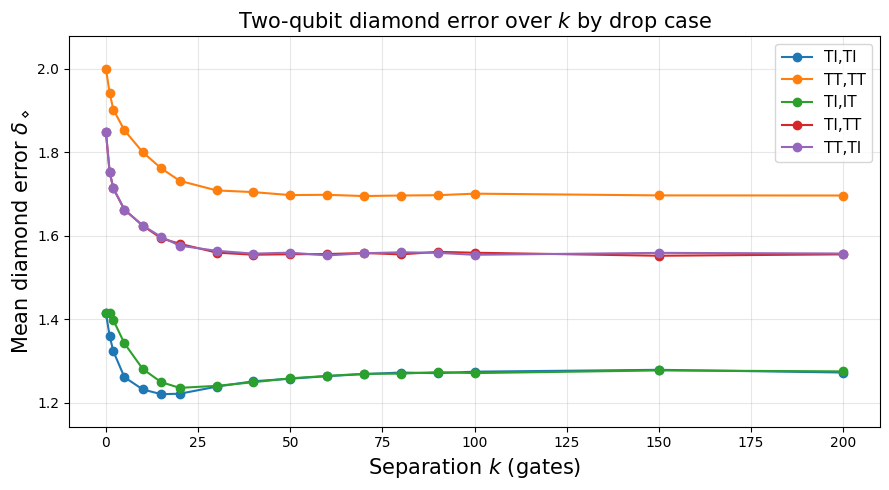

In [55]:
fig, ax = plt.subplots(figsize=(9, 5))

for label, errors in results.items():
    ax.plot(k_values, errors, 'o-',label=label)

# ax.set_ylim(1, 2.2)
ax.legend(fontsize=11, loc='upper right', bbox_to_anchor=(1.0, 1.0))
ax.margins(x=0.05, y=0.1)
ax.set_xlabel('Separation $k$ (gates)', fontsize=15)
ax.set_ylabel('Mean diamond error $\\delta_\diamond$', fontsize=15)
ax.set_title('Two-qubit diamond error over $k$ by drop case', fontsize=15)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('diamond_error_2qubit.png', dpi=150, bbox_inches='tight')
plt.show()

# Part 2: Applying Min-Cut with Error Model to get Pareto Frontier

In [56]:
import networkx as nx
from itertools import combinations

## One qubit

In [148]:
# fixing circuit length

circuit_length_1q = 60
seed = 8

In [ ]:
# functions for error model and mincut etc

def run_circuit(circuit, drop=None): # just makin a circuit
    if drop is None: drop = set()
    U = np.eye(2, dtype=complex)
    for i, (name, G) in enumerate(circuit):
        if i not in drop:
            U = G @ U
    return U

# runs the circuit once with no drops and once with drops and finds the diamond norm between them
def drop_error(circuit, drop):
    if not drop: return 0.0
    return diamond_norm(run_circuit(circuit), run_circuit(circuit, drop))


def min_switches(circuit, drop=None):
    if drop is None: drop = set()
    has_H = any(n == 'H' for n, _ in circuit)
    active_T = [i for i, (n, _) in enumerate(circuit) if n == 'T' and i not in drop]
    if not has_H or not active_T: return 0 # first check if there are no active H or T gates which means no switches are needed but this ofc wont be true for our {H, T} circuits
    G = nx.DiGraph()
    G.add_nodes_from(['s', 't'] + [f'g{i}' for i in range(len(circuit))]) # directed graph; s is the 2d code with H and t is the 3d code with T. a gate position is a node.

    # encodes weilandt et al networks construction
    INF = 1e9
    for i, (name, _) in enumerate(circuit):
        nd = f'g{i}'
        if name == 'H':
            G.add_edge('s', nd, capacity=INF); G.add_edge(nd, 's', capacity=INF) # an H is implemented in 2s so it has infty capacity (never cut) edges connecting it to s in both directions. IE pinned to 2d
        elif name == 'T' and i not in drop:
            G.add_edge('t', nd, capacity=INF); G.add_edge(nd, 't', capacity=INF) # similarly undropped T's are pinned to 3d
    for i in range(len(circuit) - 1):
        G.add_edge(f'g{i}', f'g{i+1}', capacity=1.0) # these r the temporal edges - connect consecutive gate nodes in both directions w capacity 1. if the two nodes are in diff codes then that's a switch. cutting a temporal edge = making a switch
        G.add_edge(f'g{i+1}', f'g{i}', capacity=1.0)
    return int(round(nx.minimum_cut(G, 's', 't')[0])) # min cut finds the cheapest way to partition nodes into s and t. the cost of the cut is the number of temporal edges that cross between the two groups, which equals the number of switches.

In [150]:
# circuit generation + base switches with mincut

# generates random circuit with  a certain percentage of T gates
rng = np.random.default_rng(seed)
circuit = [('T', T.copy()) if rng.random() < 0.2 else ('H', H.copy()) for _ in range(circuit_length_1q)]
t_indices = [i for i, (n, _) in enumerate(circuit) if n == 'T']
base_sw = min_switches(circuit)

print('Circuit:', ''.join(n for n, _ in circuit))
print(f'T gates: {len(t_indices)} at {t_indices}')
print()

# circuit generation and pareto frontier

# enumerate all subsets/ways to divide up the T gates (there are 2^m of these)
results = []
for r in range(len(t_indices) + 1):
    for combo in combinations(t_indices, r):
        drop = set(combo)
        err = drop_error(circuit, drop) # find drop error for eacb of them
        sw = min_switches(circuit, drop) #also find minimum switches needed for each 
        results.append((round(err, 6), sw, sorted(combo)))

# sort da results by error
results.sort(key=lambda x: x[0])
best_sw = base_sw + 1
frontier = []
for err, sw, drop in results:
    if sw < best_sw:
        frontier.append((err, sw, drop))
        best_sw = sw


Circuit: HHHHHHHHTHHHTTHHHHHHHTHHTTHHHHHHTHTHHHHTHHHTHHHHHHHHHHHHTHHT
T gates: 12 at [8, 12, 13, 21, 24, 25, 32, 34, 39, 43, 56, 59]



In [151]:
print(f"{'eps':>8}  {'switches':>8}  {'saving':>6}  dropped")
for err, sw, drop in frontier:
    print(f"{err}  {sw:8d}  {base_sw-sw:6d}  {drop}")

     eps  switches  saving  dropped
0.0        19       0  []
0.0        17       2  [12, 34]
0.0        13       6  [12, 13, 34, 39]
0.0         0      19  [8, 12, 13, 21, 24, 25, 32, 34, 39, 43, 56, 59]


In [152]:
frontier_err = [p[0] for p in frontier]
frontier_sw  = [p[1] for p in frontier]


### Plotting the Pareto Frontier

In [153]:
# import matplotlib as mpl

<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:11: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:11: SyntaxWarning: invalid escape sequence '\d'
/var/folders/hh/4jxv48xx1nv34jrj383q31yh0000gn/T/ipykernel_8566/1823572096.py:9: SyntaxWarning: invalid escape sequence '\d'
  ax.set_xlabel('Diamond error $\delta_\diamond$')
/var/folders/hh/4jxv48xx1nv34jrj383q31yh0000gn/T/ipykernel_8566/1823572096.py:11: SyntaxWarning: invalid escape sequence '\d'
  ax.set_title('Switching cost vs. minimal $\delta_\diamond$ (single qubit)')


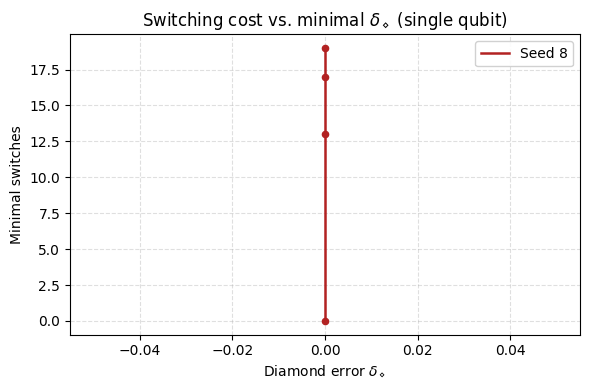

In [154]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.step(frontier_err, frontier_sw, where='post',
        color='firebrick', linewidth=1.8, zorder=3, label = f"Seed {seed}")
ax.scatter(frontier_err, frontier_sw,
           s=20, color='firebrick', zorder=4)


ax.set_xlabel('Diamond error $\delta_\diamond$')
ax.set_ylabel('Minimal switches')
ax.set_title('Switching cost vs. minimal $\delta_\diamond$ (single qubit)')
ax.legend(framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.4)


plt.tight_layout()
plt.savefig(f'pareto_single_qubit_run_{seed}.png', bbox_inches='tight')
plt.show()

### Looped for 50 runs for aggregate benchmarking

In [ ]:
records = []
 
for seed in range(1, 51):
    rng = np.random.default_rng(seed)
    circuit = [('T', T.copy()) if rng.random() < 0.2 else ('H', H.copy()) for _ in range(circuit_length_1q)]
    t_indices = [i for i, (n, _) in enumerate(circuit) if n == 'T']
    base_sw = min_switches(circuit)
 
    results = []
    for r in range(len(t_indices) + 1):
        for combo in combinations(t_indices, r):
            drop = set(combo)
            err = drop_error(circuit, drop)
            sw = min_switches(circuit, drop)
            results.append((round(err, 6), sw, sorted(combo)))
 
    results.sort(key=lambda x: x[0])
    best_sw, frontier = base_sw + 1, []
    for err, sw, drop in results:
        if sw < best_sw:
            frontier.append((err, sw, drop))
            best_sw = sw
 
    # first frontier point with eps > 0
    min_entry = next((x for x in frontier if x[0] > 0), None)
    min_eps = min_entry[0] if min_entry else None
    saving  = base_sw - min_entry[1] if min_entry else None
 
    records.append({'seed': seed, 'min_eps': min_eps, 'saving': saving})
    print(f"seed={seed:2d}  min_eps={min_eps}  saving={saving}", flush=True)


seed=37  min_eps=0.39876  saving=14
seed=38  min_eps=0.411987  saving=2
seed=39  min_eps=0.579471  saving=4
seed=40  min_eps=0.765367  saving=2
seed=41  min_eps=0.411987  saving=4
seed=42  min_eps=0.39876  saving=10
seed=43  min_eps=0.579471  saving=2
seed=44  min_eps=0.765367  saving=1
seed=45  min_eps=0.39876  saving=5
seed=46  min_eps=0.39876  saving=14
seed=47  min_eps=0.765367  saving=2
seed=48  min_eps=0.765367  saving=20
seed=49  min_eps=0.579471  saving=6
seed=50  min_eps=0.579471  saving=4


In [17]:
valid = [r for r in records if r['min_eps'] is not None]
avg_eps    = sum(r['min_eps'] for r in valid) / len(valid)
avg_saving = sum(r['saving']  for r in valid) / len(valid)
print(f"\nAverage min_eps: {avg_eps:.6f}  |  Average saving: {avg_saving:.6f}  (over {len(valid)}/{len(records)} runs)")


Average min_eps: 0.581591  |  Average saving: 5.771429  (over 35/36 runs)


In [ ]:
import pandas as pd

df = pd.DataFrame(records)
print("\n", df.to_string(index=False))

In [ ]:
# import csv
# with open('results36.csv', 'w', newline='') as f:
#     writer = csv.DictWriter(f, fieldnames=['seed', 'min_eps', 'saving'])
#     writer.writeheader()
#     writer.writerows(valid)

## Two qubits

In [117]:
# fixing circuit length

circuit_length_2q = 60
seed_2q = 51

In [107]:
# two qubit helper functions

def run_circuit_2q(circuit, drop=None):
    if drop is None: drop = set()
    U = I4.copy()
    for i, (name, G) in enumerate(circuit):
        if i not in drop:
            U = G @ U
    return U

def drop_error_2q(circuit, drop):
    if not drop: return 0.0
    return diamond_norm_2q(run_circuit_2q(circuit), run_circuit_2q(circuit, drop))

def min_switches_2q(circuit, drop=None):
    if drop is None: drop = set()
    # for 2-qubit circuits, each qubit wire has its own source/sink pin
    # but CNOT forces both qubits into the same code
    # we use the Weilandt construction extended to 2 qubits
    # each gate-qubit pair is a node; CNOT nodes are connected with infinite edges
    G = nx.DiGraph()
    G.add_node('s'); G.add_node('t')
    INF = 1e9
    L = len(circuit)
    
    # nodes: (gate_index, qubit) for qubit in {0, 1}
    for i in range(L):
        for q in range(2):
            G.add_node((i, q))
    
    for i, (name, _) in enumerate(circuit):
        if name in ('HI', 'IH'):
            q = 0 if name == 'HI' else 1
            G.add_edge('s', (i,q), capacity=INF)
            G.add_edge((i,q), 's', capacity=INF)
        elif name in ('TI', 'IT') and i not in drop:
            q = 0 if name == 'TI' else 1
            G.add_edge('t', (i,q), capacity=INF)
            G.add_edge((i,q), 't', capacity=INF)
        elif name == 'TT' and i not in drop:
            G.add_edge('t', (i,0), capacity=INF); G.add_edge((i,0), 't', capacity=INF)
            G.add_edge('t', (i,1), capacity=INF); G.add_edge((i,1), 't', capacity=INF)
        elif name in ('CNOT01', 'CNOT10'):
            # both qubits must be in same code: infinite edge between them
            G.add_edge((i,0), (i,1), capacity=INF)
            G.add_edge((i,1), (i,0), capacity=INF)
    
    # temporal edges per qubit
    for i in range(L-1):
        for q in range(2):
            G.add_edge((i,q), (i+1,q), capacity=1.0)
            G.add_edge((i+1,q), (i,q), capacity=1.0)
    
    # check if both codes are needed
    has_H = any(n in ('HI','IH') for n,_ in circuit)
    active_T = [i for i,(n,_) in enumerate(circuit) if n in ('TI','IT', 'TT') and i not in drop]
    if not has_H or not active_T: return 0
    
    return int(round(nx.minimum_cut(G, 's', 't')[0]))


In [108]:
# generate short two-qubit circuit
# TT = np.kron(T, T)
gate_names = ['HI', 'IH', 'TI', 'IT', 'TT', 'CNOT01', 'CNOT10']
gate_mats   = [HI,   IH,   TI,   IT,   TT,   CNOT01,   CNOT10]


In [118]:
# making da circuit

rng_2q_c = np.random.default_rng(seed_2q)
circuit_2q = []


for _ in range(circuit_length_2q): # 20% T gates
    r = rng_2q_c.random()
    if r < 0.20:
        pool = [('TI', TI), ('IT', IT), ('TT', TT)]
    elif r < 0.60:
        pool = [('HI', HI), ('IH', IH)]
    else:
        pool = [('CNOT01', CNOT01), ('CNOT10', CNOT10)]
    name, mat = pool[rng_2q_c.integers(len(pool))]
    circuit_2q.append((name, mat.copy()))

t_indices_2q = [i for i,(n,_) in enumerate(circuit_2q) if n in ('TI','IT','TT')]
print('Circuit:', ''.join(n+' ' for n,_ in circuit_2q))
print(f'T gates: {len(t_indices_2q)} at {t_indices_2q}')
print(f'Base switches: {min_switches_2q(circuit_2q)}')


Circuit: CNOT10 HI IH IH CNOT01 IH HI CNOT10 TT IH CNOT01 HI CNOT10 CNOT10 CNOT01 TI IT IT IT HI HI HI CNOT10 TT CNOT01 HI IT CNOT10 CNOT10 CNOT01 IH TT TI IT IH CNOT01 TI CNOT10 HI CNOT01 CNOT01 HI HI IH HI CNOT01 CNOT01 IH CNOT01 CNOT10 TI HI IH HI CNOT10 IT HI IH IH IH 
T gates: 13 at [8, 15, 16, 17, 18, 23, 26, 31, 32, 33, 36, 50, 55]
Base switches: 20


In [119]:
# pareto frontier

base_sw_2q = min_switches_2q(circuit_2q)
results_2q = []

for r in range(len(t_indices_2q) + 1):
    for combo in combinations(t_indices_2q, r):
        drop = set(combo)
        err = drop_error_2q(circuit_2q, drop)
        sw = min_switches_2q(circuit_2q, drop)
        results_2q.append((round(err, 6), sw, sorted(combo)))

results_2q.sort(key=lambda x: x[0])
best_sw, frontier_2q = base_sw_2q + 1, []
for err, sw, drop in results_2q:
    if sw < best_sw:
        frontier_2q.append((err, sw, drop))
        best_sw = sw

print(f"{'eps':>8}  {'switches':>8}  {'saving':>6}  dropped")
for err, sw, drop in frontier_2q:
    print(f"{err:8.4f}  {sw:8d}  {base_sw_2q-sw:6d}  {drop}")

     eps  switches  saving  dropped
  0.0000        20       0  []
  0.7654        18       2  [15]
  1.0420        16       4  [36, 55]
  1.0707        14       6  [8, 31, 55]
  1.0707        12       8  [8, 33, 36, 55]
  1.2934        10      10  [8, 15, 36, 55]
  1.5870         8      12  [8, 15, 36, 50, 55]
  1.8534         6      14  [8, 15, 23, 26, 36, 50, 55]
  2.0000         4      16  [8, 15, 31, 32, 33, 36, 50, 55]
  2.0000         2      18  [8, 15, 23, 26, 31, 32, 33, 36, 50, 55]
  2.0000         0      20  [8, 15, 16, 17, 18, 23, 26, 31, 32, 33, 36, 50, 55]



### Looped for 50 runs

In [114]:
records_2q = []

for seed_2q in range(1, 50):
    rng_2q_c = np.random.default_rng(seed_2q)
    circuit_2q = []
    for _ in range(circuit_length_2q):
        r = rng_2q_c.random() # fixes the probability of the random generation of the circuit so that we have 20% T gates.
        if r < 0.20:
            pool = [('TI', TI), ('IT', IT), ('TT', TT)] 
        elif r < 0.60:
            pool = [('HI', HI), ('IH', IH)]
        else:
            pool = [('CNOT01', CNOT01), ('CNOT10', CNOT10)]
        name, mat = pool[rng_2q_c.integers(len(pool))]
        circuit_2q.append((name, mat.copy()))

    t_idx = [i for i, (n, _) in enumerate(circuit_2q) if n in ('TI', 'IT', 'TT')]
    base_sw = min_switches_2q(circuit_2q)

    if not t_idx or base_sw == 0:
        records_2q.append({'seed': seed, 'min_eps': None, 'saving': None})
        print(f"seed={seed:2d}  skipped", flush=True)
        continue

    all_pts = []
    for r in range(len(t_idx) + 1):
        for combo in combinations(t_idx, r):
            drop = set(combo)
            err = drop_error_2q(circuit_2q, drop)
            sw  = min_switches_2q(circuit_2q, drop)
            all_pts.append((round(err, 6), sw, sorted(combo)))

    all_pts.sort(key=lambda x: x[0])
    best_sw = base_sw + 1
    frontier = []
    for err, sw, drop in all_pts:
        if sw < best_sw:
            frontier.append((err, sw, drop))
            best_sw = sw

    min_eps   = frontier[1][0] if len(frontier) > 1 else None
    min_entry = frontier[1]    if len(frontier) > 1 else None
    saving    = base_sw - min_entry[1] if min_entry else None

    records_2q.append({'seed': seed, 'min_eps': min_eps, 'saving': saving})
    print(f"seed={seed:2d}  min_eps={min_eps}  saving={saving}", flush=True)


seed= 1  min_eps=0.765367  saving=1
seed= 2  min_eps=0.765367  saving=2
seed= 3  min_eps=1.322876  saving=2
seed= 4  min_eps=0.765367  saving=2
seed= 5  min_eps=0.765367  saving=2
seed= 6  min_eps=1.361453  saving=4
seed= 7  min_eps=0.765367  saving=2
seed= 8  min_eps=0.579471  saving=2
seed= 9  min_eps=0.765367  saving=2
seed=10  min_eps=1.070722  saving=4
seed=11  min_eps=0.765367  saving=2
seed=12  min_eps=0.765367  saving=2
seed=13  min_eps=0.765367  saving=2
seed=14  min_eps=0.765367  saving=2
seed=15  min_eps=0.765367  saving=2
seed=16  min_eps=0.0  saving=4
seed=17  min_eps=0.765367  saving=2
seed=18  min_eps=0.765367  saving=2
seed=19  min_eps=0.765367  saving=2
seed=20  min_eps=0.765367  saving=2
seed=21  min_eps=0.765367  saving=2
seed=22  min_eps=0.751226  saving=4
seed=23  min_eps=0.579471  saving=2
seed=24  min_eps=0.765367  saving=2
seed=25  min_eps=0.765367  saving=1
seed=26  min_eps=0.765367  saving=2
seed=27  min_eps=0.765367  saving=2
seed=28  min_eps=0.765367  saving

In [115]:

valid_2q   = [r for r in records_2q if r['min_eps'] is not None]
avg_eps_2q = sum(r['min_eps'] for r in valid_2q) / len(valid_2q)
avg_sav_2q = sum(r['saving']  for r in valid_2q) / len(valid_2q)
print(f"\nAverage min_eps: {avg_eps_2q:.6f}  |  Average saving: {avg_sav_2q:.6f}  (over {len(valid_2q)}/{len(records_2q)} runs)")


Average min_eps: 0.765649  |  Average saving: 2.102041  (over 49/49 runs)


In [116]:
import csv
with open('results_2q.csv', 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=['seed', 'min_eps', 'saving'])
    writer.writeheader()
    writer.writerows(valid_2q)